# Tutorial 2: Compute topological features

This note book illustrates how one can compute topological features (persistence diagrams, Dowker persistence diagrams).

In [1]:
using Pkg
Pkg.activate("../.")
Pkg.instantiate()

  Activating project at `~/Documents/TDA_on_lung_ECM`


In [2]:
include("../src/dowker_persistence.jl")
include("../src/Eirene_var.jl")
include("../src/TDA.jl")

using .Dowker
using .Eirene_var
using .TDA
using DelimitedFiles
using DataFrames
using Plots
using CSV
using PersistenceDiagrams
gr()

Plots.GRBackend()

In [3]:
# plotting parameters
c_highlight = :deeppink2

### for point cloud
p_markersize = 5
p_markerstrokewidth = 0.1
p_imagesize = (300, 300)

### for PD
diagonal_lw = 2
pd_markersize = 15
tickfontsize = 25
PD_size = (500, 500)
inf_markerstrokewidth = 6

6

# Persistence diagrams from ECM pointcloud 

In [4]:
# load points
points = CSV.read("../data/pointcloud/ECM/ROI5.csv", DataFrame);

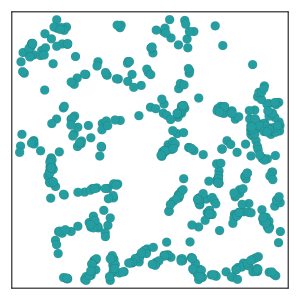

In [5]:
# # plot points
p = scatter(points[:,1], points[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                 markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 ticks = [],
                 aspect = :equal, size = p_imagesize, 
                 c = "#249EA0", # purple
                 )

plot(p)

In [6]:
PD0, PD1 = run_PH(points)

([0.0 2.0; 0.0 2.23606797749979; … ; 0.0 531.8966064941569; 0.0 Inf], [59.481089431852205 60.21627686929839; 183.5755975068582 184.39088914585776; … ; 542.3218601531751 926.0955674227148; 308.084404019418 920.3912211663038])

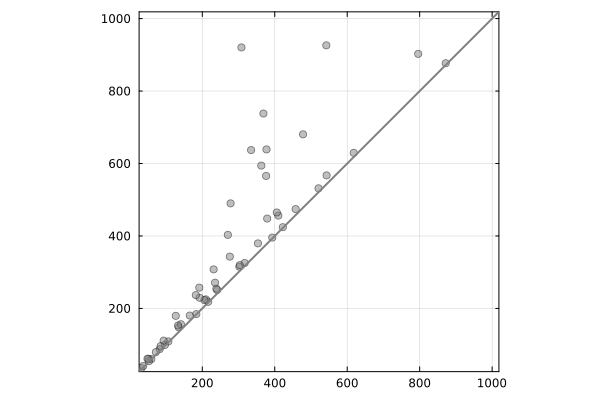

In [7]:
TDA.plot_PD(PD1, diagonal_lw= 2)

# Dimension-0 Dowker persistence diagram (DPD0)

Note: It's always a good idea to plot the two cell types and ensure that they are somewhat aligned. 

In [8]:
celltype1 = Array(CSV.read("../data/downsampled_pointcloud/cancer/ROI1.csv", DataFrame))
celltype2 = Array(CSV.read("../data/downsampled_pointcloud/leukocytes/ROI1.csv", DataFrame));

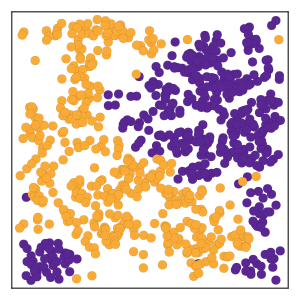

In [11]:
# plot the two cell types
p = scatter(celltype1[:,1], celltype1[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                 markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 ticks = [],
                 c =  "#592693" # purple
                 )
scatter!(p, celltype2[:,1], celltype2[:,2],
            markersize = p_markersize,
                 yflip = true,
                 label = "",
                markerstrokewidth = p_markerstrokewidth,
                 frame = :box,
                 ticks = [],
                 c = "#FAAB36" # orange
                 )
plot(p, aspect = :equal, size = p_imagesize,  
        background_color=:transparent, foreground_color=:black
        )
#savefig("figures/two_celltypes.pdf")

The following cell computes the Dowker persistence diagram. Note that Dowker persistence diagram computation takes longer than the regular persistence diagram computation. For example, the following cell will take ~5 min on a standard laptop.

In [10]:
# compute Dowker persistence diagram
DPD0, DPD1, _ = compute_Dowker(celltype1, celltype2);

Plot dimension-0 Dowker persistence diagram

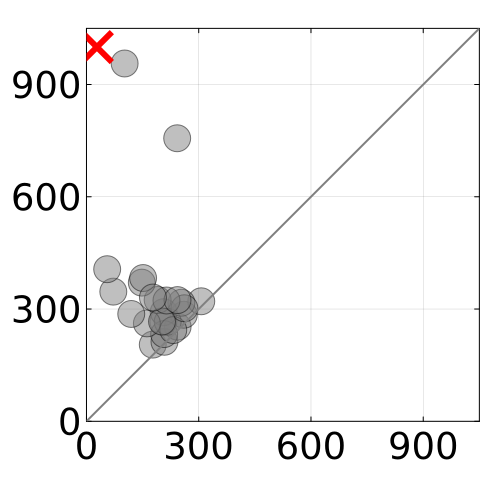

In [12]:
p = TDA.plot_PD(DPD0;
        pd_min = 0,
        pd_max = 1050,
        inf_coord = 1000,
        ticks = [0, 300, 600, 900],
        diagonal_lw = diagonal_lw,
        markersize = pd_markersize,
        #highlight = [3, 24],
        tickfontsize = tickfontsize,
        inf_markerstrokewidth = inf_markerstrokewidth,
        size = PD_size,
        right_margin = 3Plots.mm,
        background_color=:transparent, foreground_color=:black)

A persistence image vectorizes the persistence diagram. It provides a visual summary of the points on the persistence diagram.


In [15]:
# convert to Ripser PD
PH0 = array_to_ripsererPD(DPD0)

# compute PI
PI0 = PersistenceImage([PH0],  sigma=50, size = 20)

PI0(PH0)

20×20 Matrix{Float64}:
 3.26998e-7  6.58966e-7  1.25446e-6  …  1.23568e-5  8.78469e-6  5.8833e-6
 1.1323e-6   2.05669e-6  3.53703e-6     1.5181e-5   1.03449e-5  6.62802e-6
 2.99288e-6  5.02462e-6  7.95332e-6     1.13989e-5  7.36115e-6  4.47103e-6
 6.31123e-6  9.72009e-6  1.42239e-5     5.5155e-6   3.29558e-6  1.85926e-6
 1.22167e-5  1.66933e-5  2.18538e-5     1.97791e-6  1.04549e-6  5.24568e-7
 2.03724e-5  2.49654e-5  2.89782e-5  …  6.65685e-7  3.03631e-7  1.30166e-7
 2.66327e-5  3.02458e-5  3.19477e-5     2.13166e-7  9.25084e-8  3.77907e-8
 2.50476e-5  2.72696e-5  2.73041e-5     2.73477e-7  1.81274e-7  1.12602e-7
 1.48098e-5  1.58426e-5  1.55283e-5     2.16171e-6  1.52186e-6  9.8043e-7
 4.71739e-6  5.02528e-6  4.91604e-6     8.8291e-6   6.22036e-6  4.00898e-6
 7.18378e-7  7.7971e-7   8.07252e-7  …  1.70635e-5  1.20219e-5  7.74805e-6
 5.4652e-8   7.43237e-8  1.20023e-7     1.637e-5    1.15333e-5  7.43314e-6
 5.02069e-9  1.31027e-8  3.54659e-8     7.76595e-6  5.47141e-6  3.5263e-6
 6.57

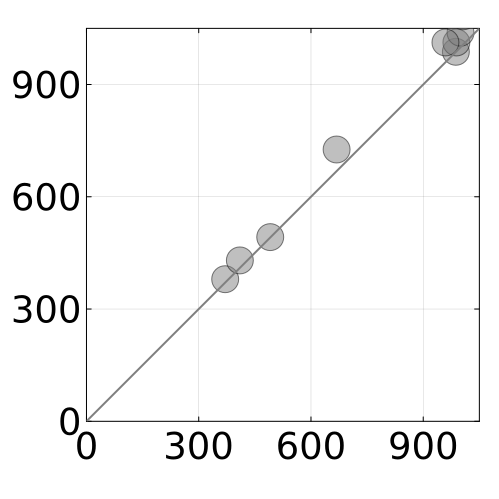

In [16]:
p = TDA.plot_PD(DPD1;
        pd_min = 0,
        pd_max = 1050,
        inf_coord = 1000,
        ticks = [0, 300, 600, 900],
        diagonal_lw = diagonal_lw,
        markersize = pd_markersize,
        #highlight = [3, 24],
        tickfontsize = tickfontsize,
        inf_markerstrokewidth = inf_markerstrokewidth,
        size = PD_size,
        right_margin = 3Plots.mm,
        background_color=:transparent, foreground_color=:black)

In [17]:
# convert to Ripser PD
PH1 = array_to_ripsererPD(DPD1)

# compute PI
PI1 = PersistenceImage([PH0],  sigma=50, size = 20)

PI1(PH1)

20×20 Matrix{Float64}:
 1.91569e-16  1.32297e-15  8.35449e-15  …  4.15384e-7   6.29903e-7
 1.09123e-16  7.53945e-16  4.76386e-15     2.5297e-7    3.87225e-7
 2.96167e-17  2.04745e-16  1.29464e-15     7.4341e-8    1.1497e-7
 3.60864e-18  2.49658e-17  1.58012e-16     9.94701e-9   1.55531e-8
 1.89325e-19  1.31105e-18  8.30755e-18     5.80465e-10  9.17812e-10
 4.18449e-21  2.90105e-20  1.84094e-19  …  1.44297e-11  2.30662e-11
 3.85777e-23  2.67834e-22  1.7026e-21      1.51079e-13  2.44016e-13
 1.47737e-25  1.02746e-24  6.54545e-24     6.62642e-16  1.08057e-15
 2.34645e-28  1.63528e-27  1.04443e-26     1.21418e-18  1.99728e-18
 1.54492e-31  1.07938e-30  6.91511e-30     9.27884e-22  1.53826e-21
 4.21692e-35  2.95506e-34  1.90011e-33  …  2.9539e-25   4.93069e-25
 4.77314e-39  3.35682e-38  2.16781e-37     3.9135e-29   6.57155e-29
 2.24144e-43  1.58303e-42  1.02752e-41     2.1559e-33   3.63883e-33
 4.3692e-48   3.10116e-47  2.02485e-46     4.93462e-38  8.36546e-38
 3.53756e-53  2.52547e-52  1.6